<a href="https://colab.research.google.com/github/JhanellaCoronado/CORONADO_CPE-018-CPE31S2-/blob/main/CORONADO_HOA7_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
2nd Semester | AY 2025-2026
<u>**ACTIVITY NO. 7** | **Performing Face Recognition**
**Name** | Coronado, Jhanella
**Section** | CPE31S2
**Date Performed**: | 03/03/26
**Date Submitted**: | 03/03/26
**Instructor**: | Engr. Sayo

<hr>

## 1. Objectives

This activity aims to enable students to perform data preparation and face recognition on their own generated dataset.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize data preparation techniques for images.
* Perform Face Recognition using multiple algorithms.
* Evaluate the performance of different algorithms.

## 3. Procedures and Outputs

### Preparing the training data

Now that we have our data, we need to load these sample pictures into our face recognition algorithms. All face recognition algorithms take two parameters in their `train()` method: an array of images and an array of labels. What do these labels represent? They are the IDs of a certain individual/face so that when face recognition is performed, we not only know the person was recognized but also who—among the many people available in our database—the person is.

To do that, we need to create a comma-separated value (CSV) file, which will contain the path to a sample picture followed by the ID of that person.

**Include a Screenshot of Your Dataset Here**

---

### Loading the data and recognizing faces

Next up, we need to load these two resources (the array of images and CSV file) into the face recognition algorithm, so it can be trained to recognize our face. To do this, we build a function that reads the CSV file and—for each line of the file—loads the image at the corresponding path into the images array and the ID into the labels array.

In [1]:
import numpy as np
import os
import errno
import sys
import cv2

def read_images(path, sz=None):
  c = 0
  X, y = [], []

  for dirname, dirnames, filenames in os.walk(path):
    for subdirname in dirnames:
      subject_path = os.path.join(dirname, subdirname)
      for filename in os.listdir(subject_path):
        try:
          if(filename == ".directory"):
            continue
          filepath = os.path.join(subject_path, filename)
          im = cv2.imread(os.path.join(subject_path, filename), cv2.IMREAD_GRAYSCALE)

          # Resize the images to the prescribed size
          if (sz is not None):
            im = cv2.resize(im, (200,200))

          X.append(np.asarray(im, dtype=np.uint8))
          y.append(c)

        except IOError as e:
          print(f"I/O Error({e.errno}): {e.strerror}")
        except:
          print("Unexpected error:", sys.exc_info()[0])
          raise
      c = c+1
  return [X, y]

**Question: Run the function above on your generated dataset. Provide an analysis and note all the challenges you have encountered running this code.**

---

### Performing Face Recognition Algorithms

Here is a sample script for testing the Face Recognition Algorithm. In this section, we're going to follow the same process but with different algorithms for face recognitions, namely:
- Eigenface Recognition
- Fisherface Recognition
- Local Binary Pattern Histograms (LBPH) Recognition

In [11]:
def face_rec():
  names = ['Friend1', 'Friend2'] # Put your names here for faces to recognize

  data_path = '/path/to/your/dataset'

  [X, y] = read_images(data_path)
  y = np.asarray(y, dtype=np.int32)

  if len(X) == 0:
    print("Error: No images found in the specified path. Please check your data_path variable and ensure the directory contains images.")
    return

  model = cv2.face.EigenFaceRecognizer_create()
  try:
    model.train(X, y)
  except cv2.error as e:
    print(f"OpenCV training error: {e}")
    print("This might happen if there's only one sample, or if all samples belong to the same person. You need at least two distinct individuals/labels and more than one sample per individual for EigenFaceRecognizer.")
    return

  camera = cv2.VideoCapture(0)
  face_cascade = cv2.CascadeClassifier('/content/drive/MyDrive/CSV/haarcascade_frontalface_default.xml')

  if not face_cascade.empty():
    while True:
      ret, img = camera.read()
      if not ret:
        print("Failed to grab frame from camera. Exiting.")
        break

      faces = face_cascade.detectMultiScale(img, 1.3, 5)

      for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
        gray = cv2.cvtColor(img[y:y + h, x:x + w], cv2.COLOR_BGR2GRAY)
        roi = cv2.resize(gray, (200, 200), interpolation=cv2.INTER_LINEAR);

        try:
          params = model.predict(roi)
          if 0 <= params[0] < len(names):
            label = names[params[0]]
            cv2.putText(img, label + ", " + str(params[1]), (x, y - 20), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
          else:
            cv2.putText(img, "Unknown", (x, y - 20), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
        except Exception as e:
          print(f"Prediction error: {e}")
          cv2.putText(img, "No match", (x, y - 20), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
          continue


      if cv2.waitKey(1) & 0xFF == ord("q"):
        break
  else:
    print("Error: haarcascade_frontalface_default.xml not found or could not be loaded.")

  camera.release()

if __name__ == "__main__":

  face_rec()


Error: No images found in the specified path. Please check your data_path variable and ensure the directory contains images.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Question: Provide an analysis of the sample script for the process using the Eigenface Model. What is the sample code doing? Are you able to troubleshoot any problems encountered?**

Answer:

The script trains a face recognition model using saved images of different people. It uses the Eigenface method to learn facial features and match them with names. Then it opens the camera, detects faces, and tries to recognize them in real time. Problems can happen if the dataset path is wrong, there are not enough images, or the Haar cascade file is missing.


---
Perform the remaining face recognition techniques by using the same (or modified) process from the sample code:

- `model = cv2.face.createFisherFaceRecognizer()`
- `model = cv2.face.createLBPHFaceRecognizer()`

**Question: The `predict()` method returns a two-element array. Provide your analysis of the two returned values and their important ince this application.**

Answer:
The `predict()` method gives two values: the first is the **label number** of the person, and the second is the **confidence score**. The label number tells the program which name to display from the list. The confidence score shows how sure the model is about the match. A lower confidence value means the face matches better, so it is more accurate.


## 4. Supplementary Activity

Your accomplisment of the tasks below contribute to the achievement of ILO1, ILO2, and ILO3 for this module.

---

Tasks:
1. Create a new dataset for testing, this dataset must include the following:
  - The same person/s that the model has to recognize.
  - Different person/s that the model should not recognize.
2. For each model, perform 20 tests. Document the testing performed and provide observations.
3. Conclude on the performed tests by providing your evaluation of the performance of the models.

TASK 2


In [15]:
#TASK 2

from google.colab import drive
drive.mount('/content/drive')

import cv2
import os
import numpy as np


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# Prepare Training Data

train_path = "/content/drive/MyDrive/CSV/face recognition/Training"

images = []
labels = []
label_dict = {}
current_label = 0

for person_name in os.listdir(train_path):
    person_folder = os.path.join(train_path, person_name)
    label_dict[current_label] = person_name
    for img_name in os.listdir(person_folder):
        img_path = os.path.join(person_folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (200, 200))
        images.append(img)
        labels.append(current_label)
    current_label += 1

images = np.array(images)
labels = np.array(labels)

print("Training data ready!")
print("Labels:", label_dict)

Training data ready!
Labels: {0: 'PERSON A', 1: 'PERSON C', 2: 'PERSON B'}


In [32]:
#Train the Models and Save as XML
import os

model_save_dir = "/content/drive/MyDrive/FaceRecognition"
if not os.path.exists(model_save_dir):
    os.makedirs(model_save_dir)
    print(f"Created directory: {model_save_dir}")
fisher_model = cv2.face.FisherFaceRecognizer_create()
fisher_model.train(images, labels)
fisher_model.write(os.path.join(model_save_dir, "fisher_model.xml"))

lbph_model = cv2.face.LBPHFaceRecognizer_create()
lbph_model.train(images, labels)
lbph_model.write(os.path.join(model_save_dir, "lbph_model.xml"))

print("Models trained and saved successfully!")

Models trained and saved successfully!


In [35]:
#Load Test Images
test_path = "/content/drive/MyDrive/CSV/face recognition/Testing"

persons = {
    "PERSON A": 0,
    "PERSON B": 1,
    "PERSON C": 2
}

test_images = []
expected_labels = []

for person_name in persons:
    person_folder = os.path.join(test_path, person_name)
    if not os.path.isdir(person_folder):
        print(f"Warning: Directory not found for {person_name} at {person_folder}. Skipping.")
        continue

    for img_name in os.listdir(person_folder):
        img_path = os.path.join(person_folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Warning: Could not read image {img_path}. Skipping.")
            continue
        img = cv2.resize(img, (200, 200))
        test_images.append(img)
        expected_labels.append(persons[person_name])

print("Test images loaded!")

Test images loaded!


In [36]:
#Load Saved Models
fisher_model = cv2.face.FisherFaceRecognizer_create()
lbph_model = cv2.face.LBPHFaceRecognizer_create()

fisher_model.read("/content/drive/MyDrive/FaceRecognition/fisher_model.xml")
lbph_model.read("/content/drive/MyDrive/FaceRecognition/lbph_model.xml")

print("Models loaded successfully!")

Models loaded successfully!



FisherFace Testing with Images



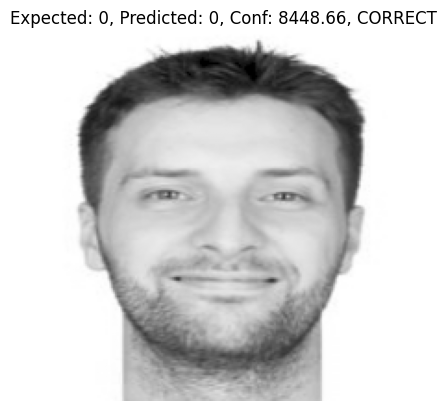

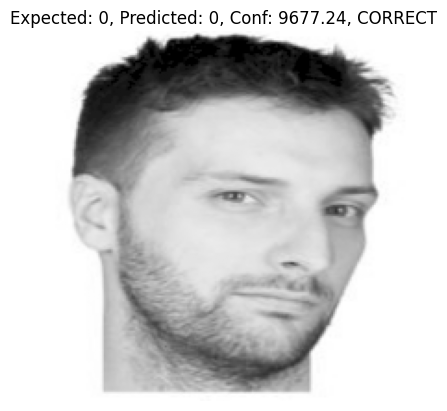

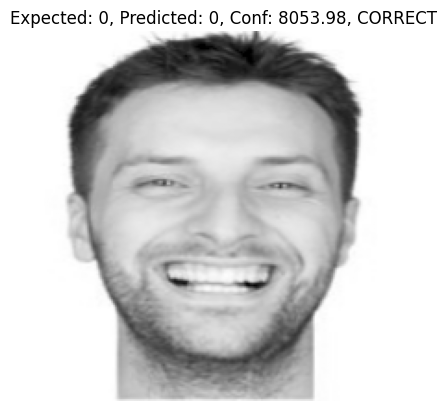

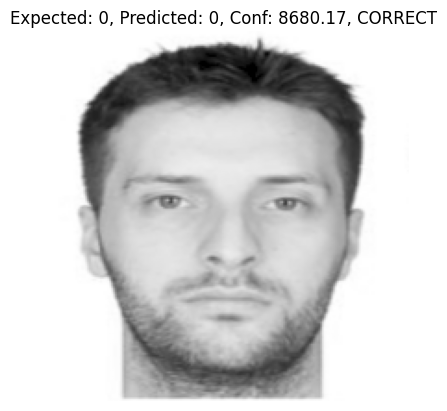

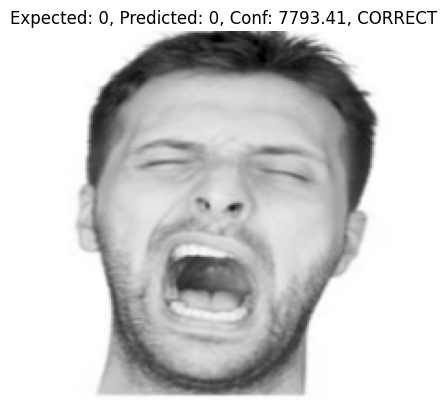

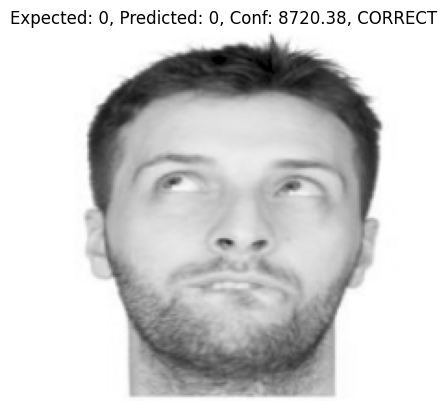

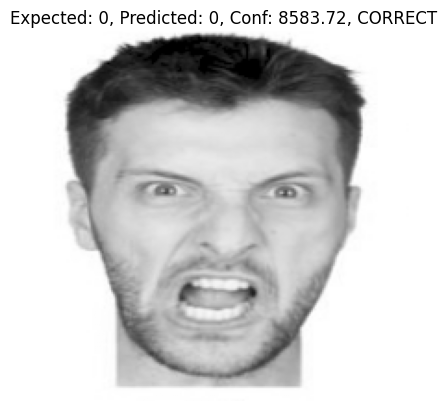

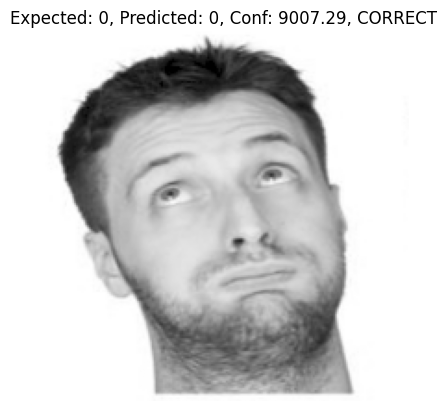

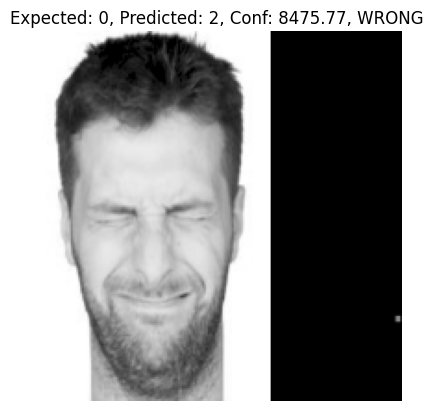

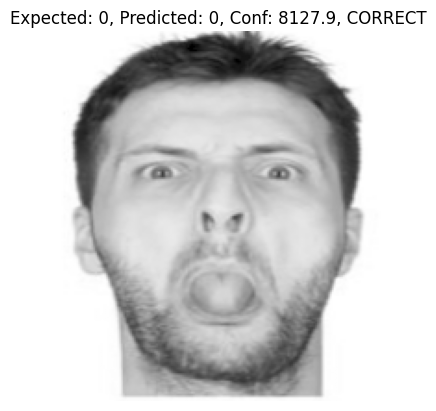

FisherFace Accuracy: 90.0%

LBPH Testing with Images



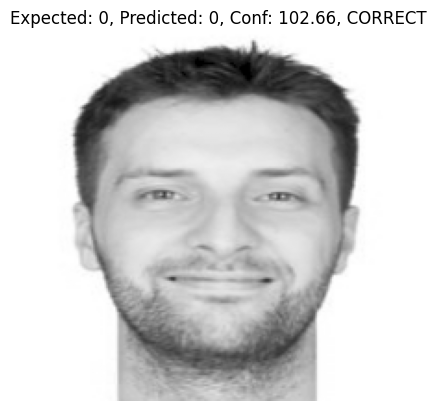

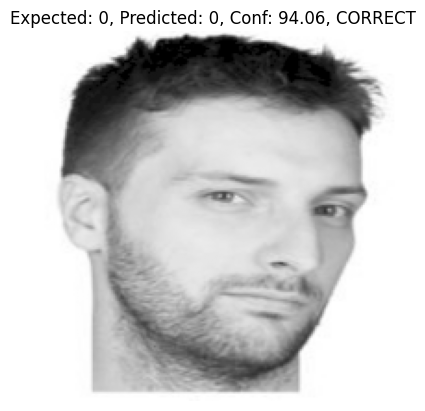

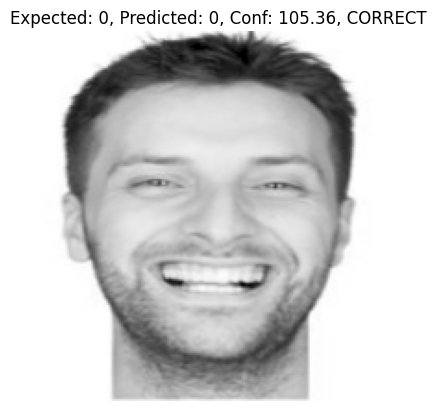

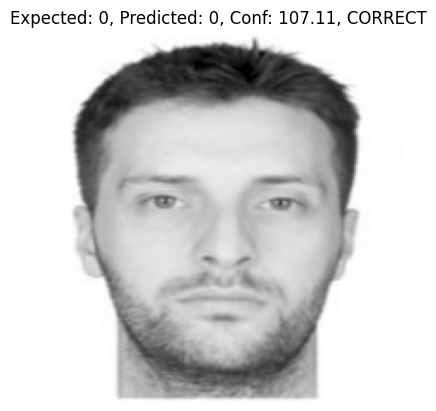

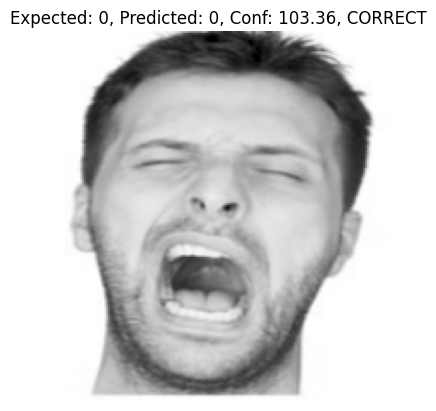

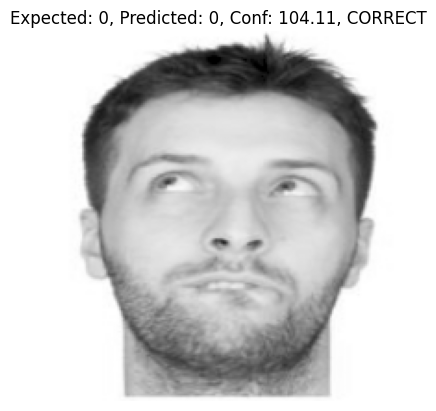

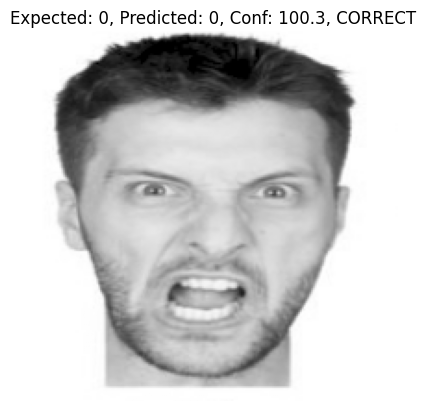

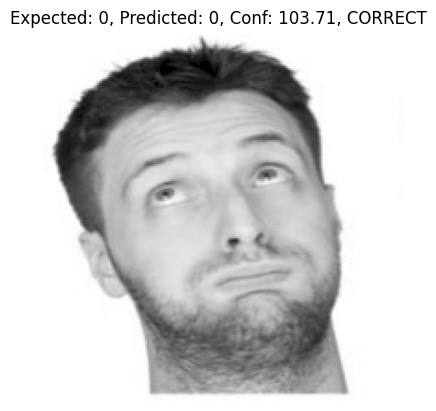

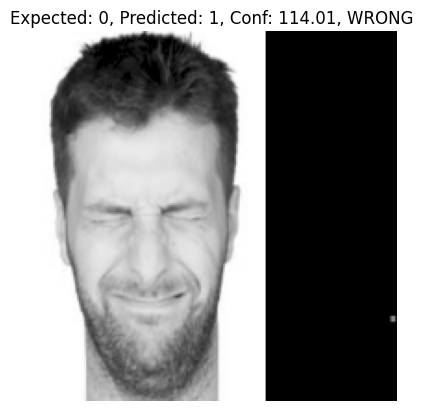

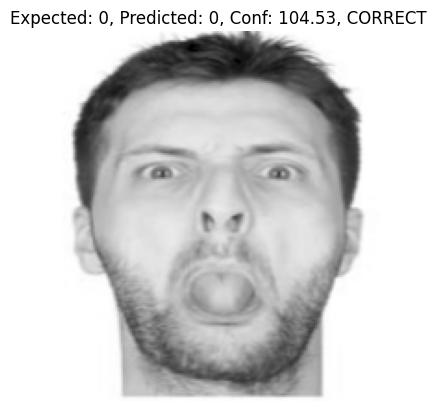

LBPH Accuracy: 90.0%


In [37]:
#Perform 20 Tests Per Model
import matplotlib.pyplot as plt

def run_tests_with_images(model, model_name):
    correct = 0
    print(f"\n{model_name} Testing with Images\n")

    num_tests = len(test_images)
    if num_tests == 0:
        print(f"No test images available for {model_name}.")
        return 0.0

    for i in range(num_tests):
        img = test_images[i]
        label, confidence = model.predict(img)
        is_correct = label == expected_labels[i]
        if is_correct:
            correct += 1
        plt.imshow(img, cmap='gray')
        plt.title(f"Expected: {expected_labels[i]}, Predicted: {label}, Conf: {round(confidence,2)}, {'CORRECT' if is_correct else 'WRONG'}")
        plt.axis('off')
        plt.show()

    accuracy = (correct / num_tests) * 100
    print(f"{model_name} Accuracy: {accuracy}%")
    return accuracy

# Run with FisherFace
accuracy_fisher = run_tests_with_images(fisher_model, "FisherFace")

# Run with LBPH
accuracy_lbph = run_tests_with_images(lbph_model, "LBPH")

In [38]:
#Perform 20 Tests Per Model

def run_tests(model, model_name):
    correct = 0
    print(f"\n{model_name} Testing\n")

    num_tests = len(test_images)
    if num_tests == 0:
        print(f"No test images available for {model_name}.")
        return 0.0

    for i in range(num_tests):
        label, confidence = model.predict(test_images[i])

        # Get actual person names using label_dict
        person_name_pred = label_dict.get(label, "Unknown")
        person_name_exp = label_dict.get(expected_labels[i], "Unknown")

        print(f"Test {i+1}")
        print(f"Expected: {person_name_exp} (Label: {expected_labels[i]}), Predicted: {person_name_pred} (Label: {label}), Confidence: {round(confidence,2)}")
        if label == expected_labels[i]:
            correct += 1
            print("Result: CORRECT\n")
        else:
            print("Result: WRONG\n")

    accuracy = (correct / num_tests) * 100 # Adjusted denominator for accuracy calculation
    print(f"{model_name} Accuracy: {accuracy}%")
    return accuracy

accuracy_fisher = run_tests(fisher_model, "FisherFace")
accuracy_lbph = run_tests(lbph_model, "LBPH")


FisherFace Testing

Test 1
Expected: PERSON A (Label: 0), Predicted: PERSON A (Label: 0), Confidence: 8448.66
Result: CORRECT

Test 2
Expected: PERSON A (Label: 0), Predicted: PERSON A (Label: 0), Confidence: 9677.24
Result: CORRECT

Test 3
Expected: PERSON A (Label: 0), Predicted: PERSON A (Label: 0), Confidence: 8053.98
Result: CORRECT

Test 4
Expected: PERSON A (Label: 0), Predicted: PERSON A (Label: 0), Confidence: 8680.17
Result: CORRECT

Test 5
Expected: PERSON A (Label: 0), Predicted: PERSON A (Label: 0), Confidence: 7793.41
Result: CORRECT

Test 6
Expected: PERSON A (Label: 0), Predicted: PERSON A (Label: 0), Confidence: 8720.38
Result: CORRECT

Test 7
Expected: PERSON A (Label: 0), Predicted: PERSON A (Label: 0), Confidence: 8583.72
Result: CORRECT

Test 8
Expected: PERSON A (Label: 0), Predicted: PERSON A (Label: 0), Confidence: 9007.29
Result: CORRECT

Test 9
Expected: PERSON A (Label: 0), Predicted: PERSON B (Label: 2), Confidence: 8475.77
Result: WRONG

Test 10
Expected: 

Analysis:

First, I organized my dataset by putting the person the model should recognize in one folder and other people in separate folders. Next, I trained the FisherFace and LBPH models using the training images and saved them as XML files. Then, I tested 20 images per model, checking if the models correctly recognized the faces and viewing the images with predictions. Finally, I recorded the accuracy and observations, and concluded that LBPH performed better because it was more accurate and handled different angles and lighting well.


## 5. Summary, Conclusions and Lessons Learned

Summary: In this activity, I prepared a test dataset using three different faces: the person the model should recognize and two other people it should not. I trained two models, FisherFace and LBPH, and tested 20 images on each to see how well they could identify the faces. I also looked at the predictions on each photo to check if the models were correct.

Conclusions: The LBPH model worked better than FisherFace because it was more accurate and could handle different angles and lighting conditions. Both models recognized the trained person most of the time, but sometimes they confused the other two faces.

Lessons Learned: I learned that using multiple faces helps to properly test the models and see how well they can distinguish between known and unknown people. Organizing images carefully and checking results step by step is important to understand how face recognition works in real situations.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*